<div align="center">
  <h1>Space Ship Titanic</h1>
</div>


In [3]:
import pandas as p

In [5]:
train = p.read_csv('SpaceshipTitanicTrain.csv')
test = p.read_csv('SpaceshipTitanicTest.csv')
passengerid = test["PassengerId"]

In [ ]:
train.shape, test.shape 
train.head()

In [ ]:
train.isnull().sum()

In [ ]:
test.isnull().sum()

In [9]:
train.drop(columns=['Name', 'PassengerId'], inplace=True)
test.drop(columns=['Name', 'PassengerId'], inplace=True)

In [ ]:
train[['HomePlanet', 'CryoSleep', 'Destination', 'VIP']] = train[['HomePlanet', 'CryoSleep', 'Destination','VIP']].fillna(method='ffill')
test[['HomePlanet', 'CryoSleep', 'Destination', 'VIP']] = test[['HomePlanet', 'CryoSleep', 'Destination','VIP']].fillna(method='ffill')

In [ ]:
train.isnull().sum()

In [12]:
train[['CabinDeck', 'CabinNum', 'CabinSize']] = train['Cabin'].str.split('/', expand=True)
test[['CabinDeck', 'CabinNum', 'CabinSize']] = train['Cabin'].str.split('/', expand=True)

In [13]:
train.drop(columns=['Cabin', 'CabinNum'], inplace=True)
test.drop(columns=['Cabin', 'CabinNum'], inplace=True)

In [ ]:
train['CabinDeck'] = train['CabinDeck'].fillna(method='ffill')
train['CabinSize'] = train['CabinSize'].fillna(method='ffill')
test['CabinDeck'] = test['CabinDeck'].fillna(method='ffill')
test['CabinSize'] = test['CabinSize'].fillna(method='ffill')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

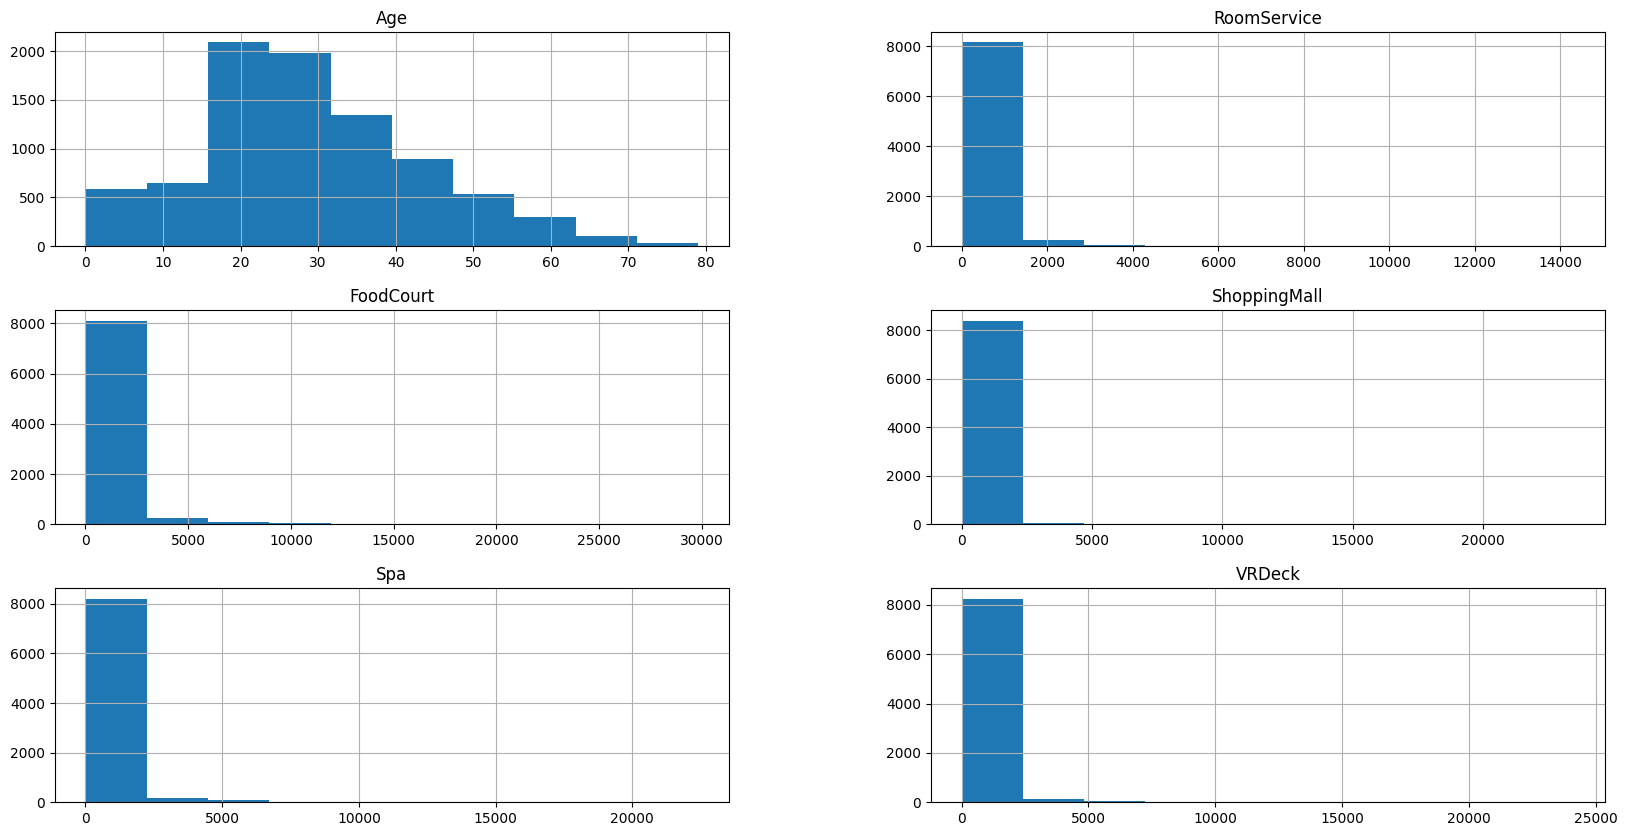

In [15]:
train.hist(figsize=(20, 10))

In [16]:
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())
train['RoomService'] = train['RoomService'].fillna(train['RoomService'].mode()[0])
test['RoomService'] = test['RoomService'].fillna(test['RoomService'].mode()[0])
train['FoodCourt'] = train['FoodCourt'].fillna(train['FoodCourt'].mode()[0])
test['FoodCourt'] = test['FoodCourt'].fillna(test['FoodCourt'].mode()[0])
train['ShoppingMall'] = train['ShoppingMall'].fillna(train['ShoppingMall'].mode()[0])
test['ShoppingMall'] = test['ShoppingMall'].fillna(test['ShoppingMall'].mode()[0])
train['Spa'] = train['Spa'].fillna(train['Spa'].mode()[0])
test['Spa'] = test['Spa'].fillna(test['Spa'].mode()[0])
train['VRDeck'] = train['VRDeck'].fillna(train['VRDeck'].mode()[0])
test['VRDeck'] = test['VRDeck'].fillna(test['VRDeck'].mode()[0])

In [ ]:
train.isnull().sum()

In [ ]:
test.isnull().sum()

In [ ]:
train.dtypes

In [20]:
train[['CryoSleep', 'VIP', 'Transported']] = train[['CryoSleep', 'VIP',
'Transported']].astype(int)
test[['CryoSleep', 'VIP']] = test[['CryoSleep', 'VIP']].astype(int)

In [ ]:
df = p.get_dummies(train, columns=['HomePlanet', 'Destination',
'CabinDeck', 'CabinSize'])
p.set_option('display.max_columns', 100)
df

In [22]:
y = df['Transported'].copy()
X = df.drop(columns='Transported').copy()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=786)

In [25]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
dtc_prediction = dtc.predict(X_test)


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix
dtc_accuracy = accuracy_score(y_test, dtc_prediction)
dtc_accuracy # 0.7372052903967797
dtc_confusion_matrix = confusion_matrix(y_test, dtc_prediction)
dtc_confusion_matrix

array([[620, 244],
       [212, 663]])

In [ ]:
#Random Forest Classifier - best model 
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=786)
rfc.fit(X_train, y_train)
rfc_prediction = rfc.predict(X_test)
rfc_accuracy = accuracy_score(y_test, rfc_prediction)
rfc_accuracy # 0.7987349051178838
rfc_confusion_matrix = confusion_matrix(y_test, rfc_prediction)
rfc_confusion_matrix

array([[722, 142],
       [206, 669]])